# Project 1 - Predict Student Dropout


 Dropout rates are a concern for higher education institutions due to their implications for both student success and institutional performance.

This project explores how demographic, academic, and socioeconomic data can be used to predict student dropout in higher education.  
Logistic Regression and SVM models are trained and evaluated to identify at-risk students and support early intervention strategies.

### Lets start by importing some relevant libraries!

In [1148]:
#Import relevant libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


### Dataset Overview

The dataset contains **4,424 records**, each representing a student enrolled in one of 17 undergraduate programs between 2007/2008 and 2018/2019 at a Portuguese institution. It includes **35 attributes** across several categories:

---

#### Demographic Features
- **Marital Status** (e.g., Single, Married, Divorced)
- **Nationality** (Portuguese, Brazilian, Ukrainian, etc.)
- **Displaced** (whether the student is living away from home)
- **Gender** (Male/Female)
- **Age at Enrollment**
- **International Student** (Yes/No)



#### Socioeconomic Features
- **Parents’ Qualifications** (e.g., Secondary Education, Bachelor's)
- **Parents’ Occupations** (e.g., Skilled Worker, Executive)
- **Special Needs**
- **Debtor Status**
- **Tuition Fees Up to Date**
- **Scholarship Holder**



#### Macroeconomic Indicators
- **Unemployment Rate**
- **Inflation Rate**
- **GDP**



#### Academic Data (at Enrollment)
- **Application Mode & Order**
- **Course Enrolled** (e.g., Informatics, Nursing, Design)
- **Attendance Regime** (Daytime or Evening)
- **Previous Qualification** (e.g., Secondary School, Higher Education)



#### Academic Performance (1st & 2nd Semester)
For each semester:
- **Number of Curricular Units (UC):** Credited, Enrolled, Evaluated, Approved
- **Average Grade**
- **Units Without Evaluation**



#### Target Variable – Final Status
- **0:** Dropout  
- **1:** Enrolled  
- **2:** Graduated  

> For this study, the target was converted into a binary classification problem in order to adress the objective directly:  
**Dropout** vs **Non-Dropout (Enrolled or Graduated)**


In [1149]:
df = pd.read_csv('dataset.csv')
df.shape


(4424, 35)

In [1150]:
df['Target'] = df['Target'].apply(lambda x: 'Dropout' if x == 'Dropout' else 'Not Dropout')
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Not Dropout
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Not Dropout
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Not Dropout


Some statistics:

In [1151]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [1152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

## Data Preprocessing

### Check for missing values

In [1153]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

With this we checked if there are missing values on the dataset, for which the conclusion is that there are not. We are good to continue.

### Change class label from "Dropout" to 0 and "Not Dropout" to 1.

In [1154]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df["Target"] = df["Target"].map({"Not Dropout": 0, "Dropout": 1})
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,1
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,1
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0


In [1155]:
df2 = df.values

X = df2[:, 0:34]
y = df2[:, 34]

X = np.array(X, dtype=np.float64)

m= len(y)

y = y.reshape(m, 1)

X.shape, y.shape


((4424, 34), (4424, 1))

## Dataset Analysis

### Imbalanced data

In the following plot, it is visible that there is a bit of descrepancy between the classes. This is a common reason for overfitting problems. For that we will adress some methods to minimize this issue. 

C:\Users\joana\AppData\Local\Temp\ipykernel_6572\2298172796.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df,  palette='viridis')


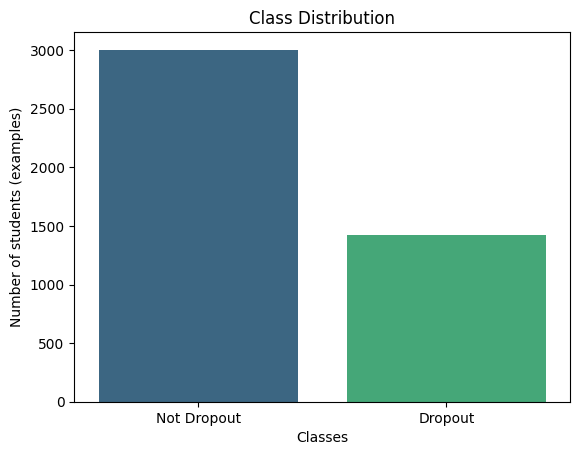

In [1156]:
sns.countplot(x='Target', data=df,  palette='viridis')
plt.xticks(ticks=[1, 0], labels=['Dropout', 'Not Dropout'])
plt.xlabel('Classes')
plt.ylabel('Number of students (examples)')
plt.title('Class Distribution')
plt.show()

## Split Data
... explain what it is for

In [1157]:
# Split data into train, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.shape, y_val.shape, y_test.shape)


(3096, 34) (664, 34) (664, 34)
(3096, 1) (664, 1) (664, 1)


### Data Balancing
### Method 1: Oversampling

There are two sampling techniques that were adressed in this work: undersampling and oversampling. Undersampling involves extracting a smaller set of majority class instances while preserving all minority class instances. This technique is suitable for large-scale applications where the number of majority samples is very high. However, it is important to note that discarding data can lead to the loss of informative instances from the majority class and degrade classifier performance.

On the other hand, oversampling involves increasing the number of minority class instances by replicating them. In this case, there is no loss of information.

After using both methods, we concluded that under-sampling performed better overral (and more espacifically, on the recall score - evaluation metric preferred for the problem in hand).

In [1158]:
"""# Import the necessary libraries
from imblearn.over_sampling import SMOTE

# Creating an instance of SMOTE
smote = SMOTE()

# Balancing the data
X_train, y_train = smote.fit_resample(X_train, y_train)

# Convert to a DataFrame for Seaborn
df_resampled = pd.DataFrame({'Target': y_train})

# Plot the count distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df_resampled, palette='viridis')
plt.xticks(ticks=[0, 1], labels=['Dropout', 'Not Dropout'])  
plt.xlabel('Classes')
plt.ylabel('Number of students')
plt.title('Balanced Class Distribution after SMOTE')
plt.show()"""

"# Import the necessary libraries\nfrom imblearn.over_sampling import SMOTE\n\n# Creating an instance of SMOTE\nsmote = SMOTE()\n\n# Balancing the data\nX_train, y_train = smote.fit_resample(X_train, y_train)\n\n# Convert to a DataFrame for Seaborn\ndf_resampled = pd.DataFrame({'Target': y_train})\n\n# Plot the count distribution\nplt.figure(figsize=(6, 4))\nsns.countplot(x='Target', data=df_resampled, palette='viridis')\nplt.xticks(ticks=[0, 1], labels=['Dropout', 'Not Dropout'])  \nplt.xlabel('Classes')\nplt.ylabel('Number of students')\nplt.title('Balanced Class Distribution after SMOTE')\nplt.show()"

### Method 2: Under-sampling

C:\Users\joana\AppData\Local\Temp\ipykernel_6572\2175003158.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df_resampled, palette='viridis')


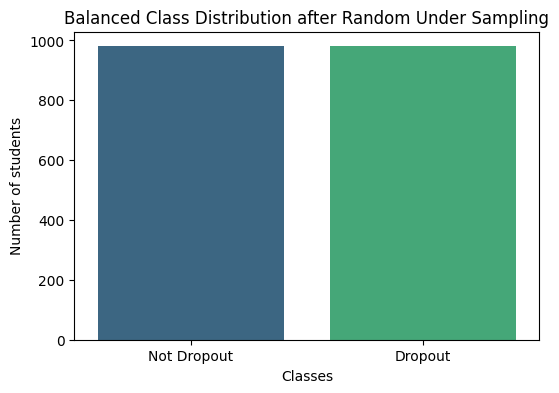

In [1159]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42, sampling_strategy = "all")
X_train, y_train = rus.fit_resample(X_train, y_train)

df_resampled = pd.DataFrame({'Target': y_train})

plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df_resampled, palette='viridis')
plt.xticks(ticks=[1, 0], labels=['Dropout', 'Not Dropout'])
plt.xlabel('Classes')
plt.ylabel('Number of students')
plt.title('Balanced Class Distribution after Random Under Sampling')
plt.show()

Important note: validation and test sets remain untouched in order to preserve the integrity of this sets as well as avoiding information leakage. 

## Feature Standardization

We'll first take a look at our features distribution before feature scaling. Feature standardization is a preprocessing technique used to ensure that features contribute equally to the learning process, especially when they have different scales.

In [1160]:
feature_names = ["Marital status", "Application mode", "Application order", "Course",
"Daytime/evening attendance", "Previous qualification", "Nacionality",
"Mother's qualification", "Father's qualification",
"Mother's occupation", "Father's occupation", "Displaced",
"Educational special needs", "Debtor", 'Tuition fees up to date',
'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
'Curricular units 1st sem (credited)',
'Curricular units 1st sem (enrolled)',
'Curricular units 1st sem (evaluations)',
'Curricular units 1st sem (approved)',
'Curricular units 1st sem (grade)',
'Curricular units 1st sem (without evaluations)',
'Curricular units 2nd sem (credited)',
'Curricular units 2nd sem (enrolled)',
'Curricular units 2nd sem (evaluations)',
'Curricular units 2nd sem (approved)',
'Curricular units 2nd sem (grade)',
'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
'Inflation rate', 'GDP']


feature_names = [f"Feature_{i+1}" for i in range(X_train.shape[1])]

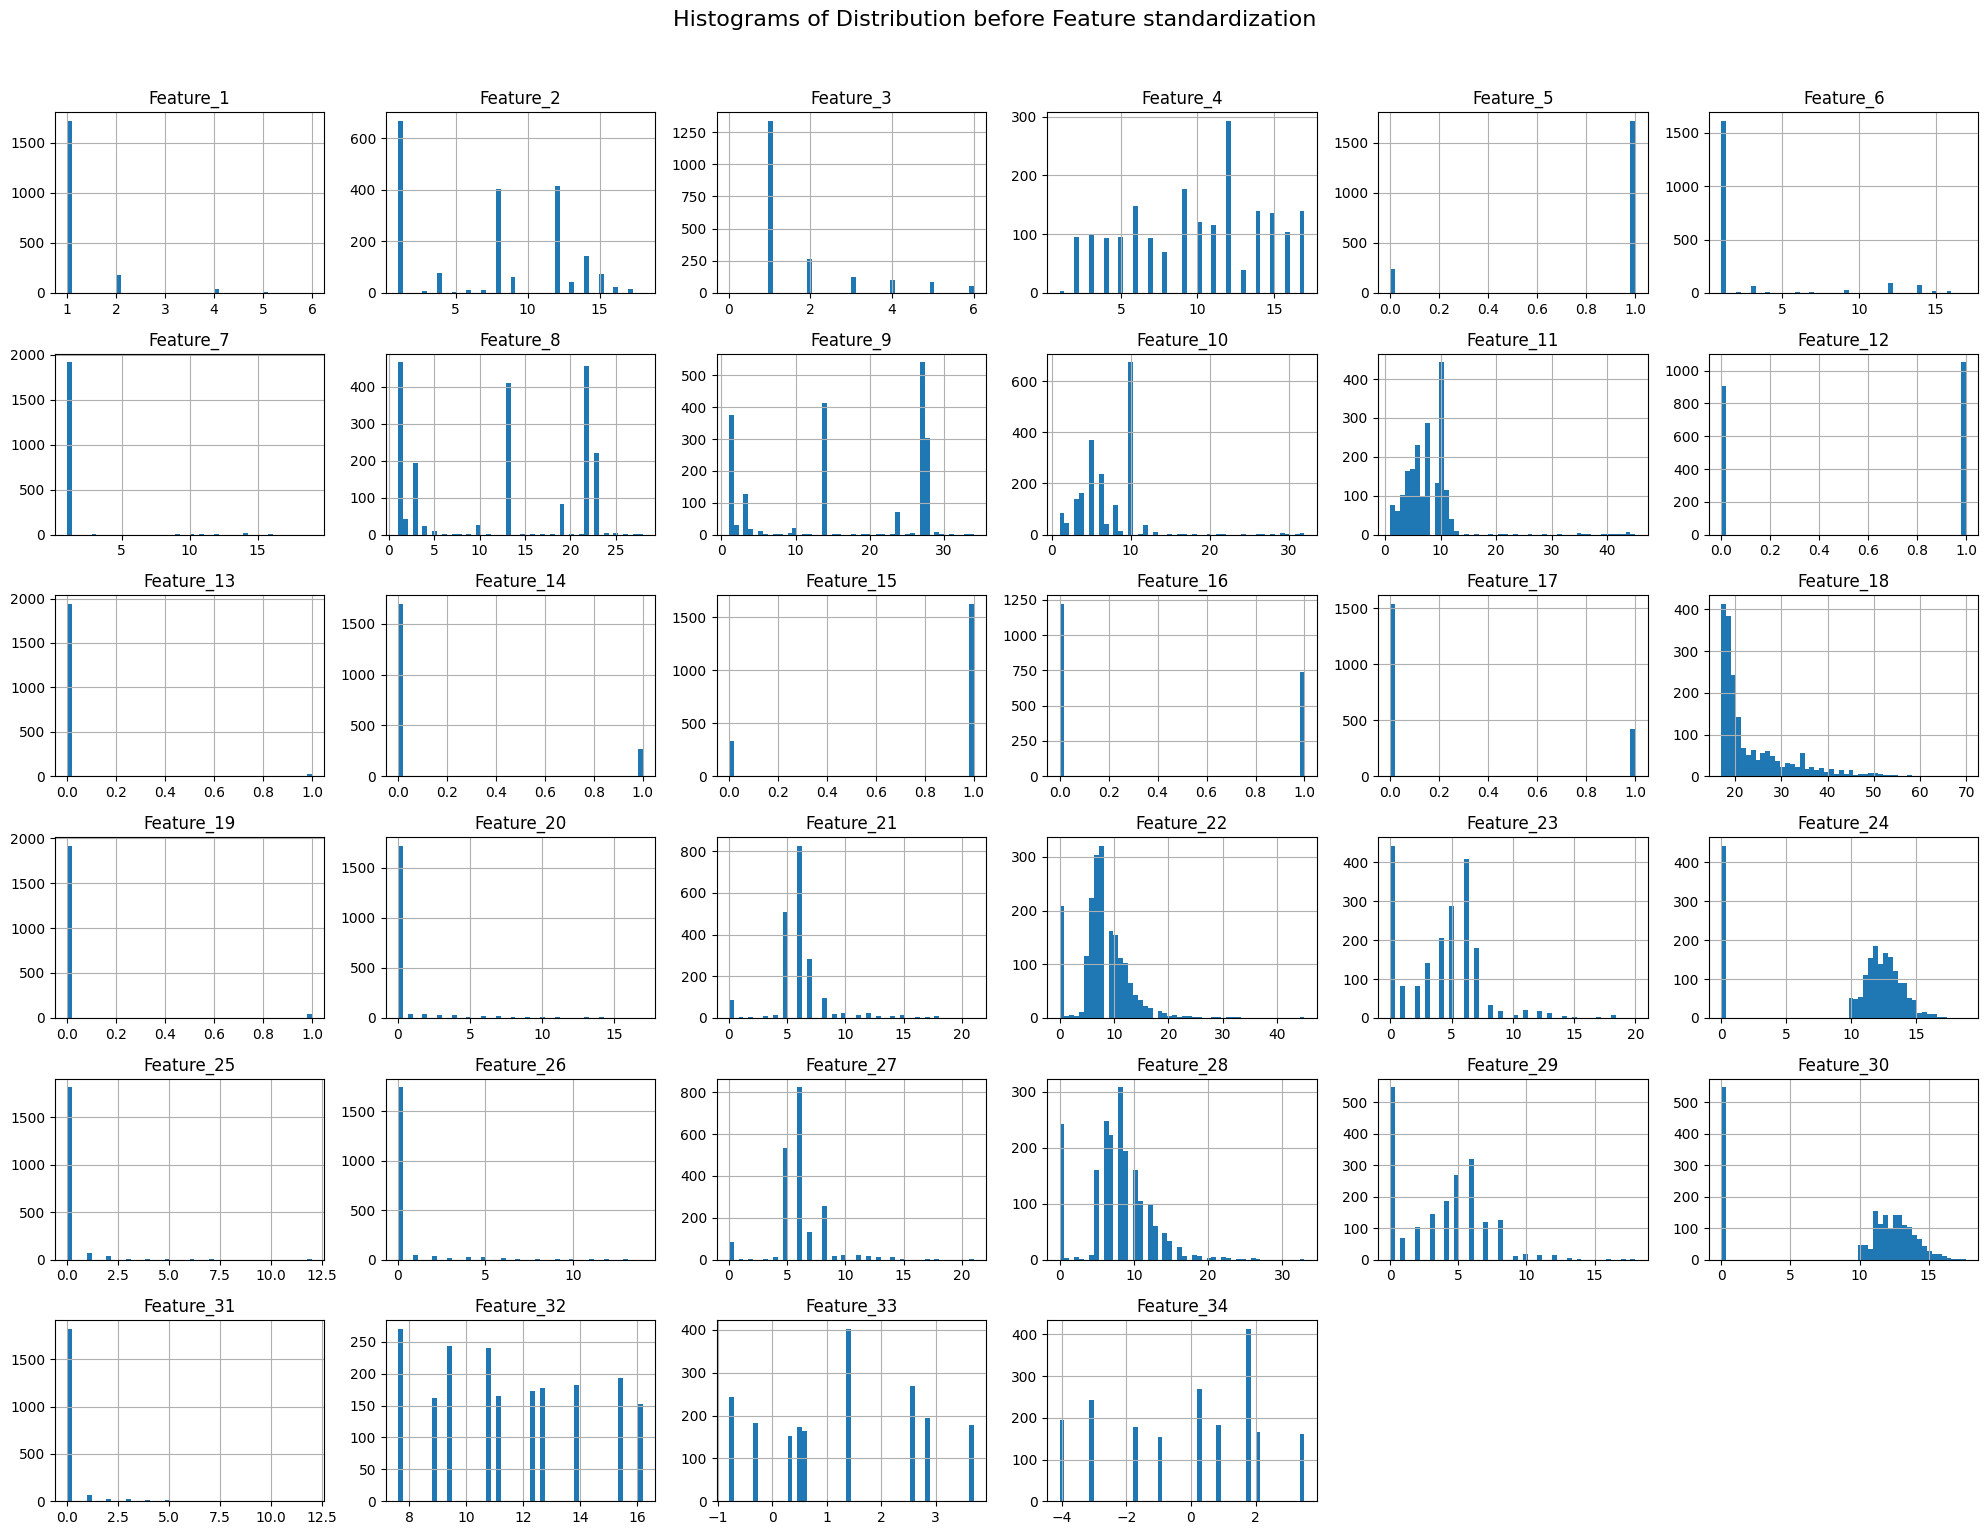

In [1161]:

df = pd.DataFrame(X_train,  columns=feature_names)
df.hist(bins=50, figsize=(20,15))
plt.suptitle("Histograms of Distribution before Feature standardization", y=1.02, fontsize=16)
plt.subplots_adjust(hspace=0.5)
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Less features for representation on report

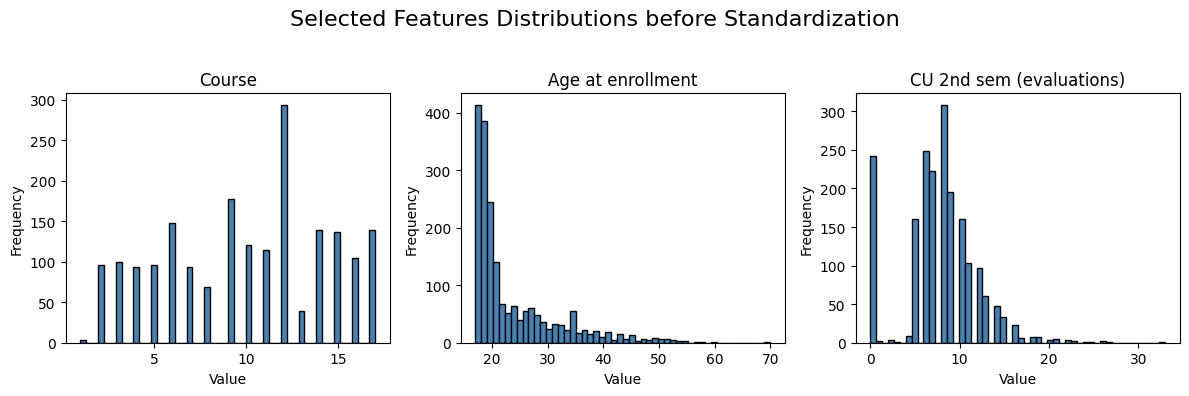

In [1162]:
import matplotlib.pyplot as plt

selected_features = ['Feature_4', 'Feature_18', 'Feature_28']
df_subset = pd.DataFrame(X_train, columns=feature_names)[selected_features]

# Criar figura e eixos
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 linha, 3 colunas

# Gerar histogramas manualmente
feature_name = ['Course', 'Age at enrollment', 'CU 2nd sem (evaluations)']
for i, feature in enumerate(selected_features):
    axes[i].hist(df_subset[feature], bins=50, color='steelblue', edgecolor='black')
    axes[i].set_title(feature_name[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

fig.suptitle("Selected Features Distributions before Standardization", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # espaço para título
plt.show()


In [1163]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


## Data visualization

In this part we resorted to histograms, boxplots and heatmaps. This step is very important for various reasons. One being because this dataset contains a lot of features (34), and so it is only sensible to use visual representations of the data we're working with, to gain information and draw conclusions. 
 1) The histograms will give us an overview of the distribution of each feature.
 2) On the contrary of the histograms, we only plotted few boxplots to gain some insights of the difference between each feature.
 3) The heatpmap is a very useful type of data visualization as it gives exceptional information about the correlation between feature and bewtween each feature and the target.

In [1164]:
df_train_norm = pd.DataFrame(X_train, columns=feature_names)
df_train_norm["Target"] = y_train.ravel() 

### 1. Histograms

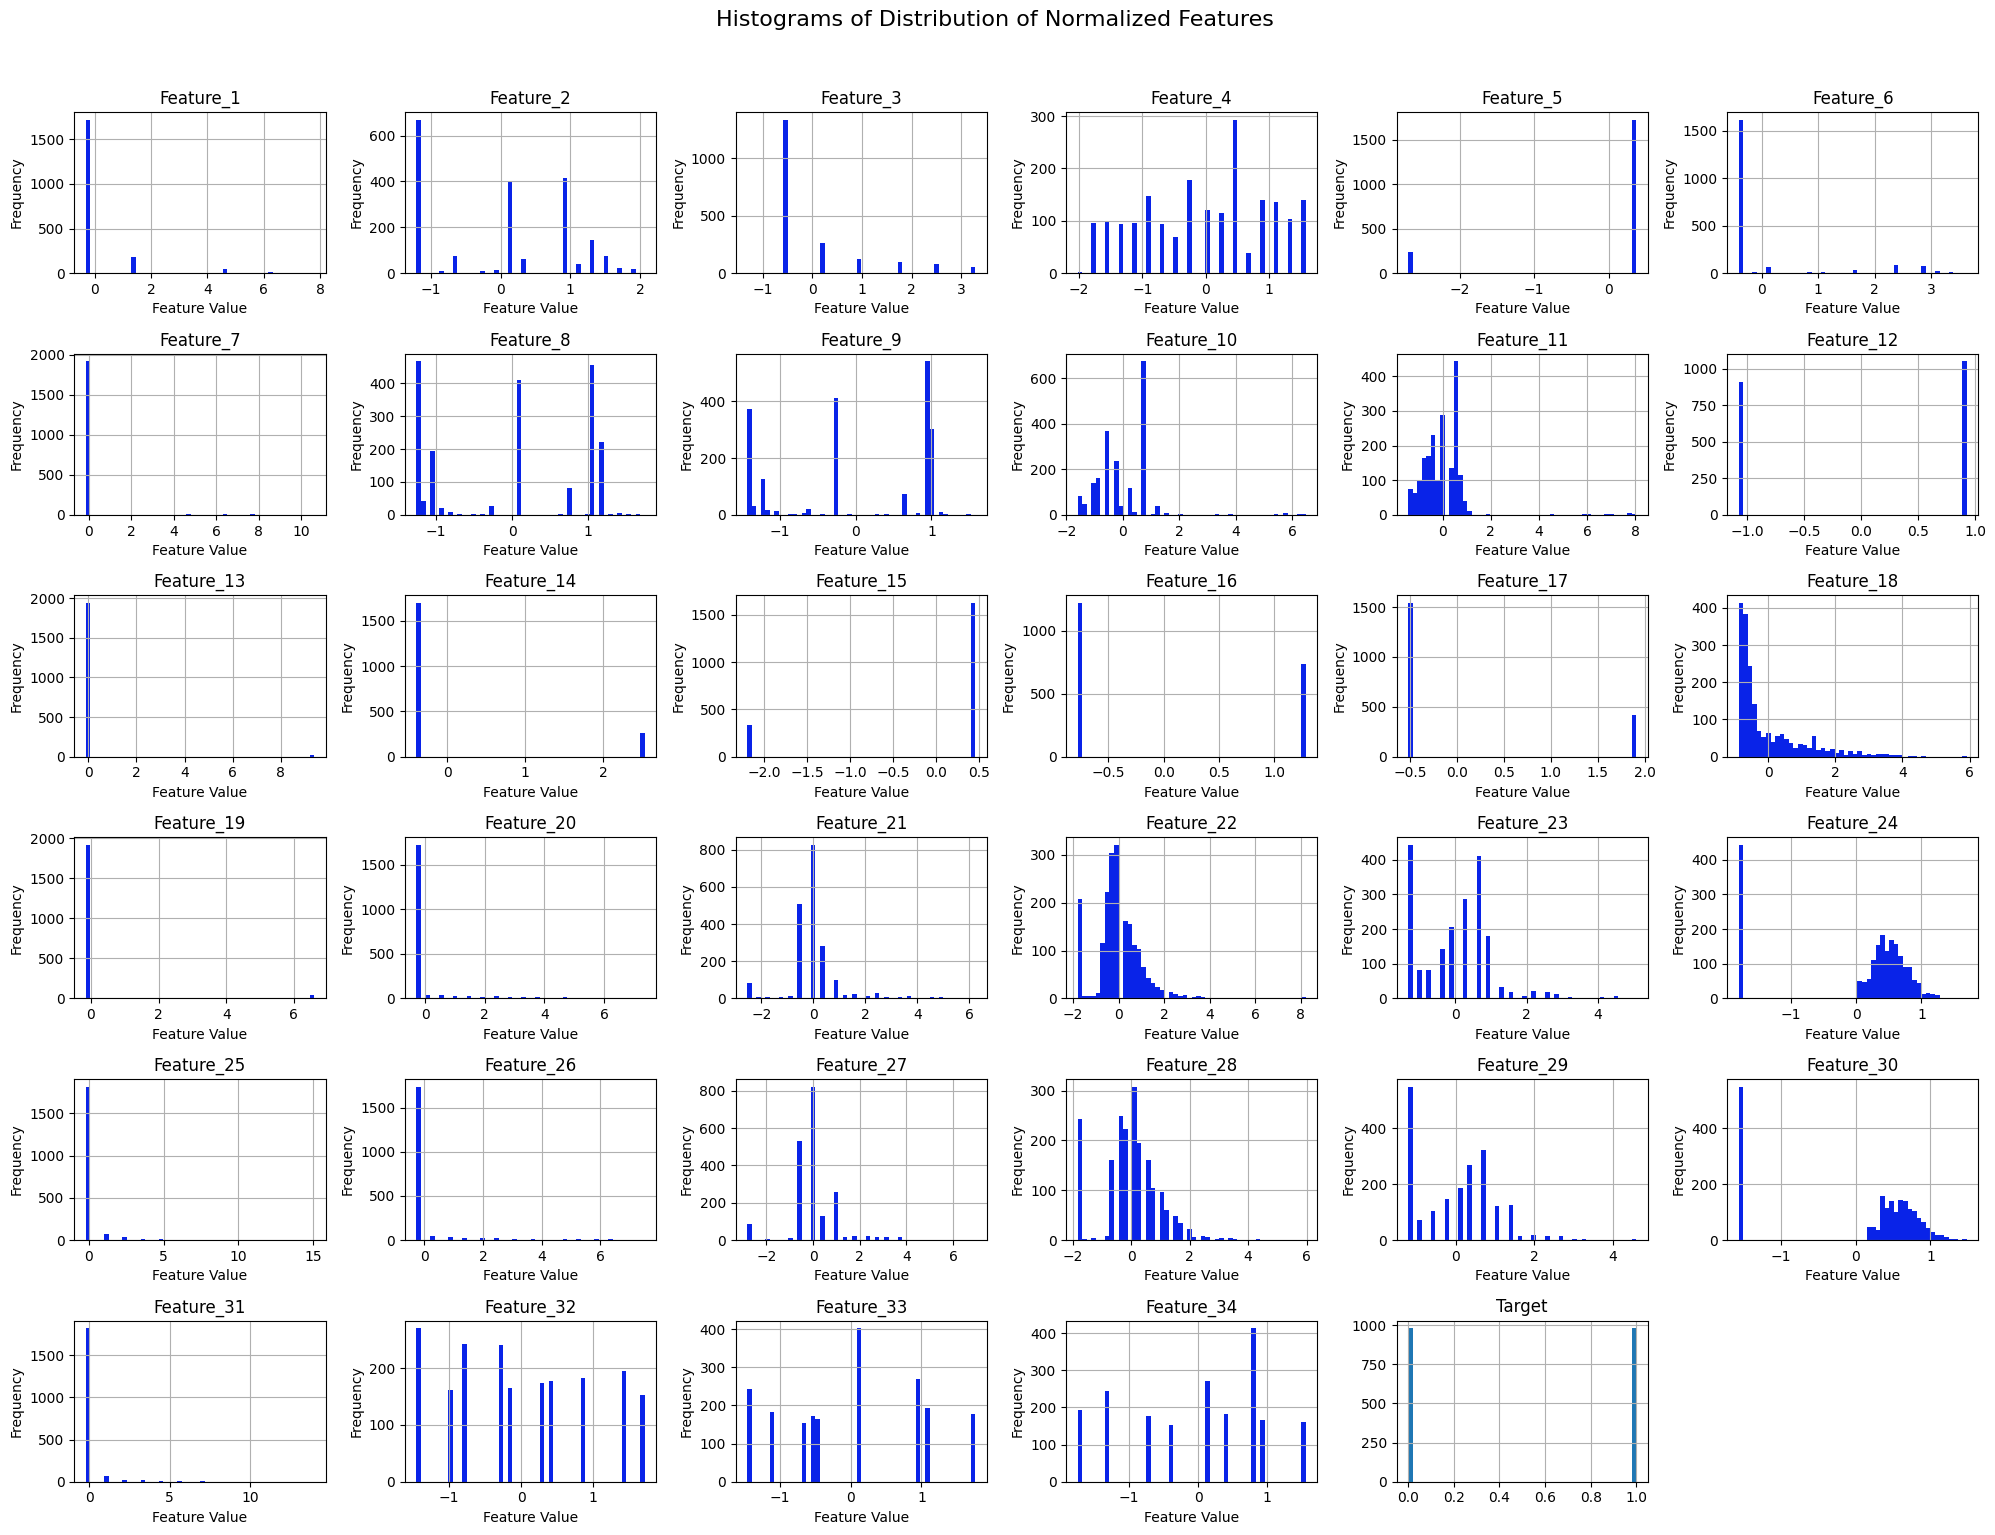

In [1165]:
df_train_norm.hist(bins=50, figsize=(20,15))
plt.suptitle("Histograms of Distribution of Normalized Features", y=1.02, fontsize=16)
plt.subplots_adjust(hspace=0.5)
for i in range(len(feature_names)):
    plt.subplot(6, 6, i+1)
    plt.hist(df_train_norm[feature_names[i]], bins=50, color='blue', alpha=0.7)
    plt.title(feature_names[i])
    plt.xlabel("Feature Value")
    plt.ylabel("Frequency")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

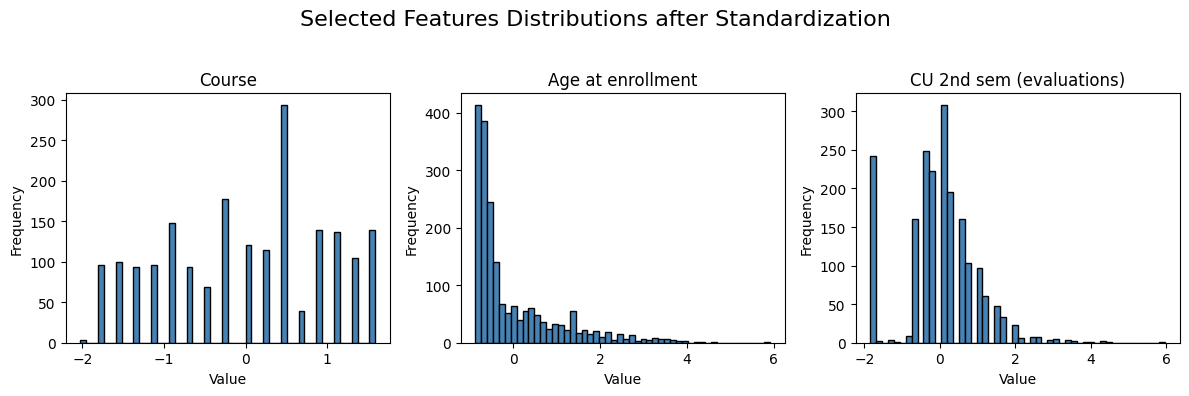

In [1166]:
import matplotlib.pyplot as plt

selected_features = ['Feature_4', 'Feature_18', 'Feature_28']
df_subset = pd.DataFrame(X_train, columns=feature_names)[selected_features]

# Criar figura e eixos
fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 linha, 3 colunas

# Gerar histogramas manualmente
feature_names = ['Course', 'Age at enrollment', 'CU 2nd sem (evaluations)']
for i, feature in enumerate(selected_features):
    axes[i].hist(df_subset[feature], bins=50, color='steelblue', edgecolor='black')
    axes[i].set_title(feature_names[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

fig.suptitle("Selected Features Distributions after Standardization", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # espaço para título
plt.show()


This histogram gives a general distribution of each feature from the train set already normalized of the dataset and of the target (already seen).

### 2. Boxplots

Let's compare 2 features:
- Feature 21 (Curricular units 1st sem (enrolled) by Dropout Status)
- Feature 29 (Curricular units 2nd sem (approved))

C:\Users\joana\AppData\Local\Temp\ipykernel_6572\2087731832.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Dropout', y='Feature_21', palette="Set2")
C:\Users\joana\AppData\Local\Temp\ipykernel_6572\2087731832.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Dropout', y='Feature_29', palette="Set2")


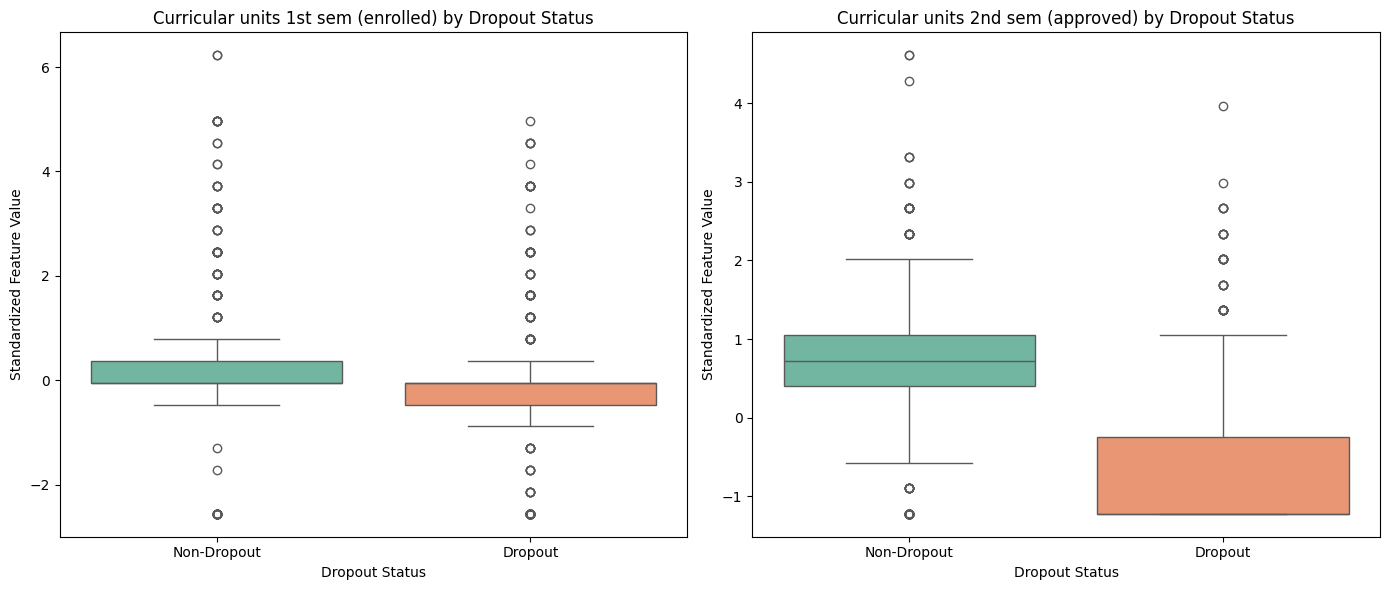

In [1167]:
X_train_df = pd.DataFrame(X_train, columns=[f'Feature_{i+1}' for i in range(X_train.shape[1])])

df_plot = X_train_df.copy()
df_plot['Dropout'] = y_train  

df_plot['Dropout'] = df_plot['Dropout'].map({1: 'Dropout', 0: 'Non-Dropout'})

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_plot, x='Dropout', y='Feature_21', palette="Set2")
plt.title("Curricular units 1st sem (enrolled) by Dropout Status")
plt.xlabel("Dropout Status")
plt.ylabel("Standardized Feature Value")

plt.subplot(1, 2, 2)
sns.boxplot(data=df_plot, x='Dropout', y='Feature_29', palette="Set2")
plt.title("Curricular units 2nd sem (approved) by Dropout Status")
plt.xlabel("Dropout Status")
plt.ylabel("Standardized Feature Value")
plt.tight_layout()
plt.show()

From this graphic representation of boxplots we can conclude some things, such as the relevance each of this feature has for the model.
It's notorious that - even though in the first case the meadian of Non-Dropouts is relatively higher then those of Dropouts - the second feature gives much more information of the difference between the two classes.
Non-Dropouts students tend to have more CU's aproved in 2nd semester than dropout students, which in many cases those values are zero.

### 3. Heatmap (Correlation Matrix)

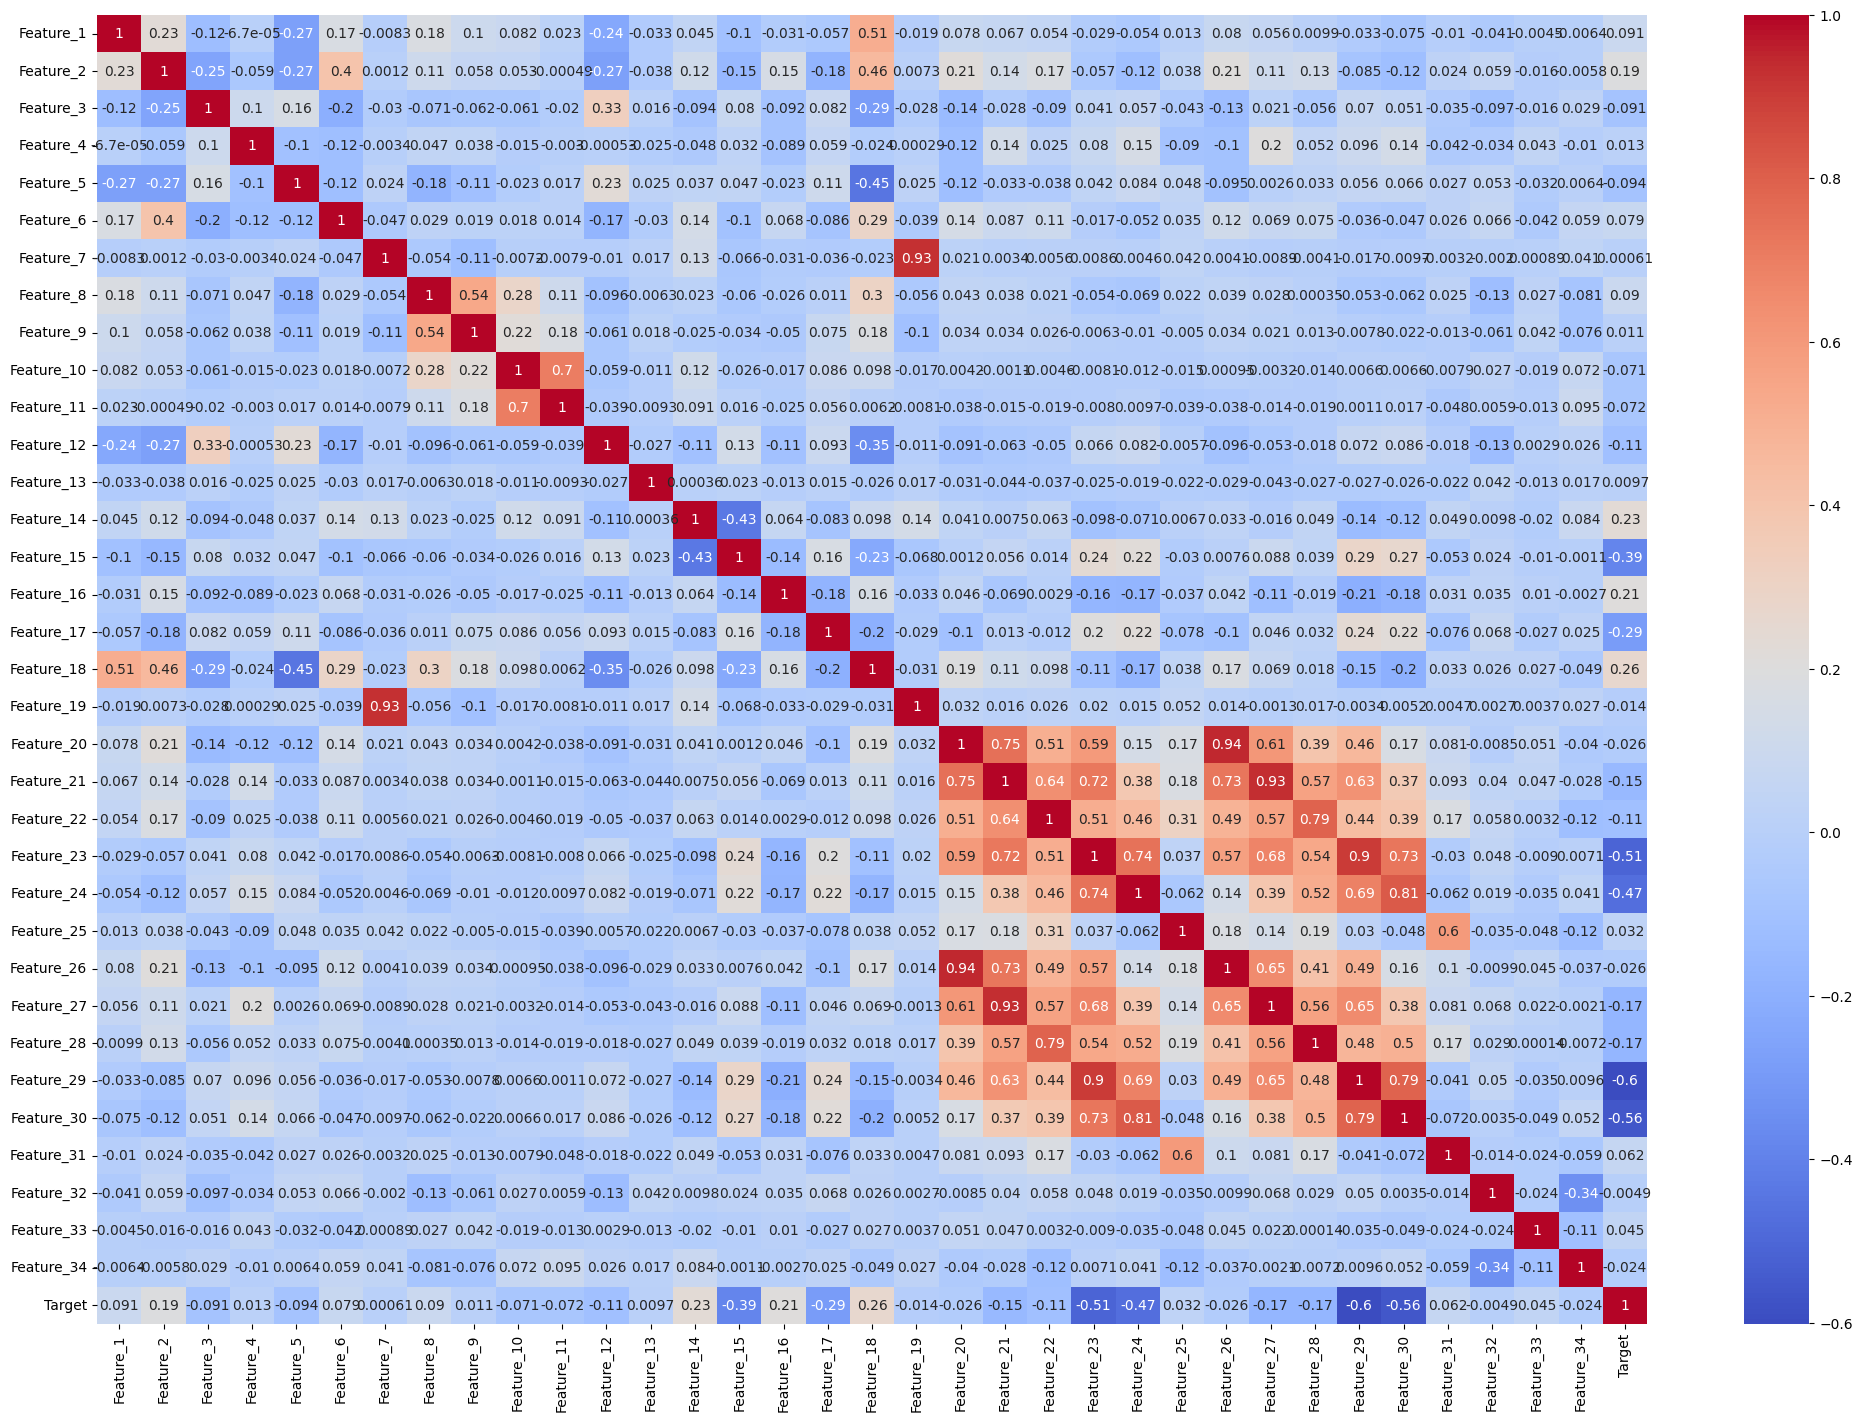

In [1168]:
corr_matrix = df_train_norm.corr()
plt.figure(figsize=(25, 17))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


# Model Training

3 models will be used for training, those being:

     - Logistic Regression  
     - Support Vector Machine
     - Random Forest

### 1. Choose best kerner for SVM with cross validation 

In [1169]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = {}

for kernel in ['linear', 'rbf']:
    svm = make_pipeline(SVC(kernel=kernel, C=1, probability=True))

    cv_scores = cross_validate(
        svm, X_train, y_train,
        cv=10,
        scoring=scoring,
        return_train_score=False
    )

    results[kernel] = {
        metric: cv_scores[f'test_{metric}'].mean()
        for metric in scoring
    }

# Mostrar resultados como DataFrame
df_kernels = pd.DataFrame(results).T
df_kernels.index = [f"SVM ({k})" for k in df_kernels.index]
df_kernels = df_kernels.round(4)

from IPython.display import display
display(df_kernels)


,accuracy,precision,recall,f1,roc_auc
SVM (linear),0.8546,0.8789,0.8235,0.8500,0.9197
SVM (rbf),0.8434,0.8685,0.8102,0.8379,0.9101


### 2. Train models

This first part's objective is to train the models with default hyperparameter values, such as C=1. Also, for each of the models, we evaluated using the validation set with the metrics:
precision score, recall, f1-score, accuracy, confusion matrix and ROC curve (AUC as well).



=== LogReg (L2) ===
Train Accuracy: 0.8582, F1: 0.8540
Val Accuracy: 0.8584, F1: 0.8042
Train and Validation F1 are reasonably close.

Classification report (Validation):
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.87      0.89       433
     Dropout       0.78      0.84      0.80       231

    accuracy                           0.86       664
   macro avg       0.84      0.85      0.85       664
weighted avg       0.86      0.86      0.86       664


=== LogReg (No Penalty) ===
Train Accuracy: 0.8561, F1: 0.8517
Val Accuracy: 0.8569, F1: 0.8025
Train and Validation F1 are reasonably close.

Classification report (Validation):
              precision    recall  f1-score   support

 Non-Dropout       0.91      0.87      0.89       433
     Dropout       0.77      0.84      0.80       231

    accuracy                           0.86       664
   macro avg       0.84      0.85      0.85       664
weighted avg       0.86      0.86      0.86      

,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
LogReg (L2),0.8582,0.8799,0.8296,0.8540,0.9288
LogReg (No Penalty),0.8561,0.8785,0.8265,0.8517,0.9288
SVM (Linear),0.8602,0.8854,0.8276,0.8555,0.9271



=== Validation Set Metrics ===


,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
LogReg (L2),0.8584,0.7751,0.8355,0.8042,0.9205
LogReg (No Penalty),0.8569,0.7720,0.8355,0.8025,0.9207
SVM (Linear),0.8569,0.7698,0.8398,0.8033,0.9173


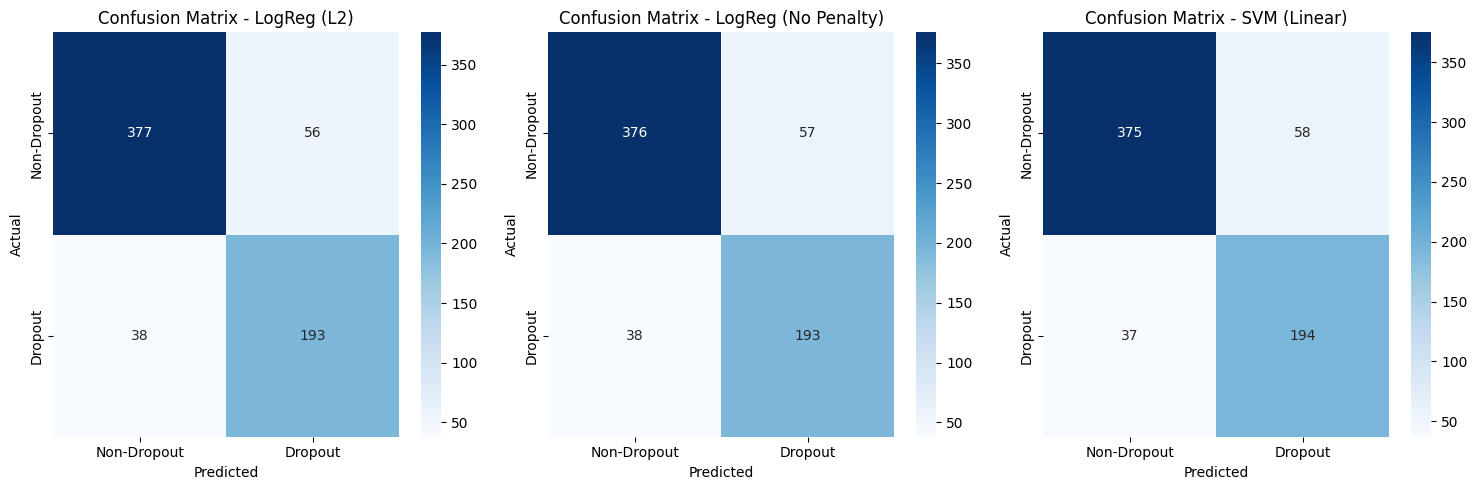

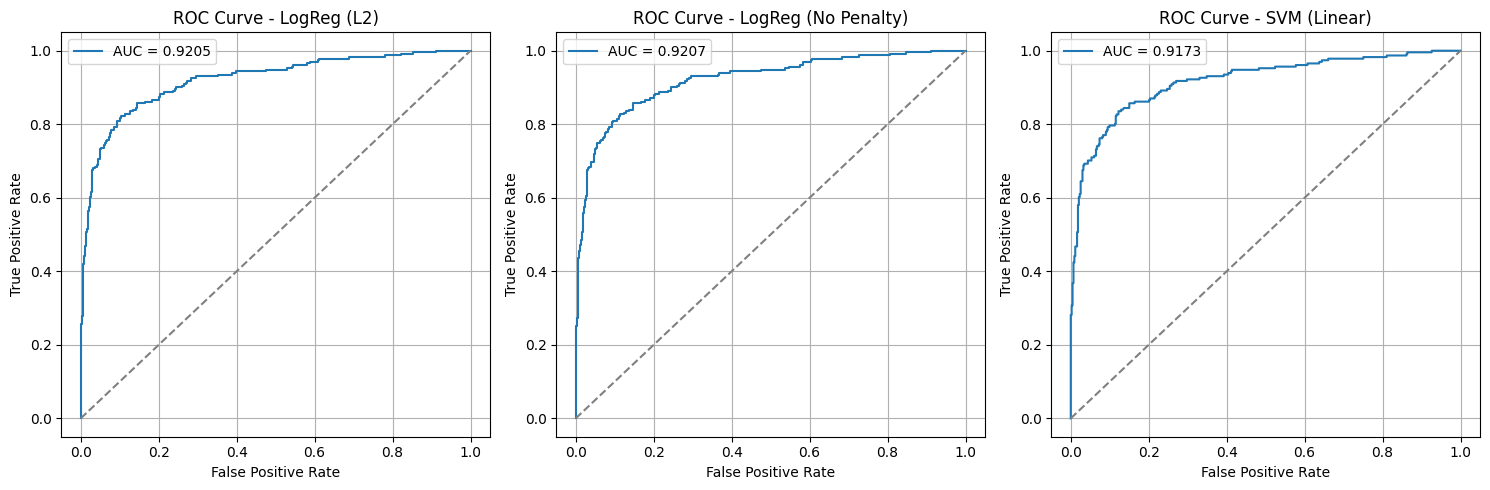

In [1170]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

lr = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)
lr.fit(X_train, y_train)

lr_no_penalty = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42)
lr_no_penalty.fit(X_train, y_train)

svm = SVC(kernel='linear', C=1, probability=True, random_state=42)
svm.fit(X_train, y_train)

models = {
    "LogReg (L2)": lr,
    "LogReg (No Penalty)": lr_no_penalty,
    "SVM (Linear)": svm
}

train_results = []
val_results = []
conf_matrices = {}
roc_data = {}

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred)
    train_rec = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    if hasattr(model, "predict_proba"):
        y_train_proba = model.predict_proba(X_train)[:, 1]
        train_auc = roc_auc_score(y_train, y_train_proba)
    else:
        train_auc = None

    train_results.append({
        "Model": name,
        "Accuracy": train_acc,
        "Precision": train_prec,
        "Recall": train_rec,
        "F1 Score": train_f1,
        "AUC": train_auc
    })

    y_val_pred = model.predict(X_val)

    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val)[:, 1]
        val_auc = roc_auc_score(y_val, y_val_proba)
        fpr, tpr, _ = roc_curve(y_val, y_val_proba)
        roc_data[name] = (fpr, tpr, val_auc)
    else:
        y_val_proba = None
        val_auc = None

    val_acc = accuracy_score(y_val, y_val_pred)
    val_prec = precision_score(y_val, y_val_pred)
    val_rec = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    val_results.append({
        "Model": name,
        "Accuracy": val_acc,
        "Precision": val_prec,
        "Recall": val_rec,
        "F1 Score": val_f1,
        "AUC": val_auc
    })

    print(f"\n=== {name} ===")
    print("Train Accuracy:", f"{train_acc:.4f}, F1:", f"{train_f1:.4f}")
    print("Val Accuracy:", f"{val_acc:.4f}, F1:", f"{val_f1:.4f}")
    if abs(train_f1 - val_f1) > 0.05:
        print("Note: Potential over/under-fitting due to large gap in F1 scores.")
    else:
        print("Train and Validation F1 are reasonably close.")
    
    print("\nClassification report (Validation):")
    print(classification_report(y_val, y_val_pred, target_names=['Non-Dropout', 'Dropout']))

    conf_matrices[name] = confusion_matrix(y_val, y_val_pred)

df_train = pd.DataFrame(train_results).set_index("Model")
df_val = pd.DataFrame(val_results).set_index("Model")

print("\n=== Train Set Metrics ===")
display(df_train.round(4))

print("\n=== Validation Set Metrics ===")
display(df_val.round(4))

fig, axes = plt.subplots(1, len(conf_matrices), figsize=(15, 5))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Dropout', 'Dropout'],
                yticklabels=['Non-Dropout', 'Dropout'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

if len(roc_data) > 0:
    fig, axes = plt.subplots(1, len(roc_data), figsize=(15, 5))
    for ax, (name, (fpr, tpr, auc_val)) in zip(axes, roc_data.items()):
        ax.plot(fpr, tpr, label=f'AUC = {auc_val:.4f}')
        ax.plot([0, 1], [0, 1], '--', color='gray')
        ax.set_title(f'ROC Curve - {name}')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()


## 3. Feature Selection

Before choosing hyperparameter values, let's first choose the most relevant features to try combatting overfitting.
This will be adressed via lasso regression

In [1171]:
original_feature_names = df_train_norm.drop(columns=["Target"]).columns.tolist()
X_train_df = pd.DataFrame(X_train, columns=original_feature_names)

lasso = LogisticRegression(penalty='l1', C=0.10, solver='liblinear') 
lasso.fit(X_train_df, y_train)

coefficients = lasso.coef_[0]

selected_features = [name for name, coef in zip(X_train_df.columns, coefficients) if coef != 0]

print("Features selected by Lasso:")
print(selected_features)
print("Discarded features:")
print([name for name in X_train_df.columns if name not in selected_features])

X_train_lasso = X_train_df[selected_features]
X_val_lasso = pd.DataFrame(X_val, columns=original_feature_names)[selected_features]
X_test_lasso = pd.DataFrame(X_test, columns=original_feature_names)[selected_features]


Features selected by Lasso:
['Feature_4', 'Feature_6', 'Feature_8', 'Feature_9', 'Feature_10', 'Feature_11', 'Feature_12', 'Feature_14', 'Feature_15', 'Feature_16', 'Feature_17', 'Feature_18', 'Feature_19', 'Feature_20', 'Feature_23', 'Feature_26', 'Feature_27', 'Feature_29', 'Feature_30', 'Feature_31', 'Feature_32']
Discarded features:
['Feature_1', 'Feature_2', 'Feature_3', 'Feature_5', 'Feature_7', 'Feature_13', 'Feature_21', 'Feature_22', 'Feature_24', 'Feature_25', 'Feature_28', 'Feature_33', 'Feature_34']


## 4. Comparing models with and without feature selection

In [1172]:
baseline_scores = {}
lasso_scores = {}

def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return {
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred)
    }

models = {
    "Logistic Regression": LogisticRegression(C=1, penalty='l2', solver='liblinear'),
    "SVM (linear)": SVC(C=1, kernel='linear', probability=True)
}

for name, model in models.items():
    baseline_scores[name] = evaluate_model(name, model, X_train, y_train, X_val, y_val)

for name, model in models.items():
    lasso_scores[name] = evaluate_model(name, model, X_train_lasso, y_train, X_val_lasso, y_val)

df_baseline = pd.DataFrame.from_dict(baseline_scores, orient='index')
df_lasso = pd.DataFrame.from_dict(lasso_scores, orient='index')

print("Performance on Full Feature Set:")
display(df_baseline.round(4))

print("\nPerformance on Lasso-Selected Feature Set:")
display(df_lasso.round(4))


Performance on Full Feature Set:


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.8584,0.7751,0.8355,0.8042
SVM (linear),0.8569,0.7698,0.8398,0.8033



Performance on Lasso-Selected Feature Set:


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.8554,0.7711,0.8312,0.8000
SVM (linear),0.8539,0.7702,0.8268,0.7975


From this we can conclude that the models performs equally in general when training with the full and less set of features. Both the accuracy and the predictive power for the Dropout class are similar, but it is notourious that both models perform better with the whole dataset.

Altough the differnece is minimal, it is prefered to use the dataset whose performance is better, for that purpose, the next step will be to choose hyperparameters with the full set of features. 

## 5. Hyper Parameter Tunining

c:\Users\joana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\joana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\joana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\joana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataC


Logistic Regression (5-fold CV):


,accuracy,precision,recall,f1,roc_auc,mean_score
C,,,,,,
0.01,0.8464,0.7743,0.7880,0.7797,0.8986,0.8174
0.10,0.8539,0.7878,0.7967,0.7909,0.9071,0.8273
0.50,0.8479,0.7723,0.8011,0.7851,0.9078,0.8228
1.00,0.8434,0.7625,0.8011,0.7798,0.9068,0.8187
2.00,0.8448,0.7660,0.8011,0.7813,0.9063,0.8199
5.00,0.8464,0.7671,0.8054,0.7840,0.9058,0.8218
10.00,0.8479,0.7703,0.8054,0.7857,0.9057,0.8230


Best Logistic Regression C: 0.1  |  Mean Score: 0.8273

SVM (linear Kernel) (5-fold CV):


,accuracy,precision,recall,f1,roc_auc,mean_score
C,,,,,,
0.01,0.8524,0.8003,0.7665,0.7821,0.9048,0.8212
0.10,0.8479,0.7842,0.7837,0.7823,0.9071,0.8210
0.50,0.8569,0.7973,0.7969,0.7957,0.9092,0.8312
1.00,0.8555,0.7943,0.7969,0.7936,0.9093,0.8299
2.00,0.8570,0.7976,0.7969,0.7952,0.9086,0.8311
5.00,0.8540,0.7940,0.7926,0.7909,0.9087,0.8280
10.00,0.8540,0.7940,0.7926,0.7909,0.9086,0.8280


Best SVM C: 0.5  |  Mean Score: 0.8312


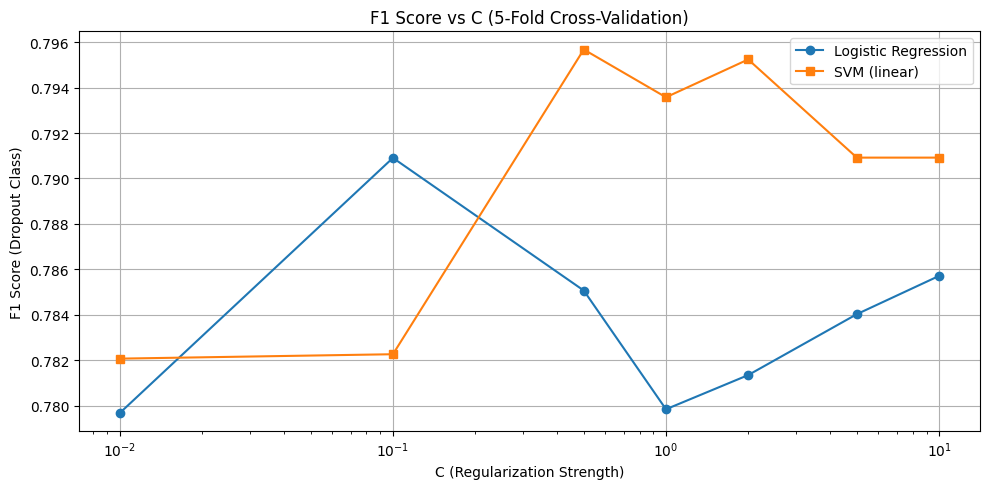

In [1173]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import  f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

C_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]

val_results = {
    "Logistic Regression": [],
    "SVM (linear Kernel)": []
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

for C in C_values:
    model = LogisticRegression(C=C, solver='liblinear', class_weight='balanced', random_state=42)
    scores = cross_validate(model, X_val, y_val, cv=10, scoring=scoring)
    metrics = {m: np.mean(scores[f'test_{m}']) for m in scoring}
    metrics["C"] = C
    metrics["mean_score"] = np.mean([metrics[m] for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]])
    val_results["Logistic Regression"].append(metrics)

for C in C_values:
    model = SVC(C=C, kernel='linear', probability=True, class_weight='balanced', random_state=42)
    scores = cross_validate(model, X_val, y_val, cv=10, scoring=scoring)
    metrics = {m: np.mean(scores[f'test_{m}']) for m in scoring}
    metrics["C"] = C
    metrics["mean_score"] = np.mean([metrics[m] for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]])
    val_results["SVM (linear Kernel)"].append(metrics)

df_lr = pd.DataFrame(val_results["Logistic Regression"]).set_index("C")
df_svm = pd.DataFrame(val_results["SVM (linear Kernel)"]).set_index("C")

print("\nLogistic Regression (5-fold CV):")
display(df_lr.round(4))
best_lr = df_lr["mean_score"].idxmax()
print(f"Best Logistic Regression C: {best_lr}  |  Mean Score: {df_lr.loc[best_lr, 'mean_score']:.4f}")

print("\nSVM (linear Kernel) (5-fold CV):")
display(df_svm.round(4))
best_svm = df_svm["mean_score"].idxmax()
print(f"Best SVM C: {best_svm}  |  Mean Score: {df_svm.loc[best_svm, 'mean_score']:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(df_lr.index, df_lr["f1"], marker='o', label='Logistic Regression')
plt.plot(df_svm.index, df_svm["f1"], marker='s', label='SVM (linear)')
plt.xscale('log')
plt.xlabel("C (Regularization Strength)")
plt.ylabel("F1 Score (Dropout Class)")
plt.title("F1 Score vs C (5-Fold Cross-Validation)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Model Final Evaluation on Test Set 


=== 5-FOLD CROSS-VALIDATION RESULTS ===

Logistic Regression:
Accuracy: 0.8601 ± 0.0102
Precision: 0.8632 ± 0.0062
Recall: 0.8283 ± 0.0220
F1: 0.8452 ± 0.0128
Roc_auc: 0.9230 ± 0.0095

SVM (linear Kernel):
Accuracy: 0.8559 ± 0.0090
Precision: 0.8613 ± 0.0079
Recall: 0.8200 ± 0.0210
F1: 0.8400 ± 0.0116
Roc_auc: 0.9212 ± 0.0089


=== FINAL EVALUATION ON TEST SET ===

Logistic Regression - Test Set:
              precision    recall  f1-score   support

 Non-Dropout       0.92      0.87      0.89       454
     Dropout       0.75      0.83      0.79       210

    accuracy                           0.86       664
   macro avg       0.83      0.85      0.84       664
weighted avg       0.86      0.86      0.86       664


SVM (linear Kernel) - Test Set:
              precision    recall  f1-score   support

 Non-Dropout       0.92      0.86      0.89       454
     Dropout       0.74      0.85      0.79       210

    accuracy                           0.86       664
   macro avg       0.8

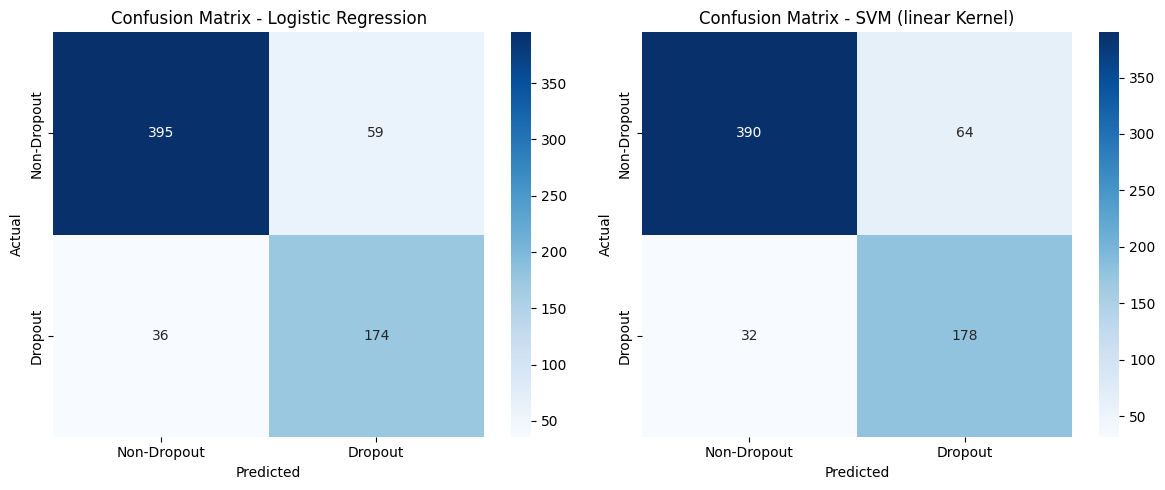

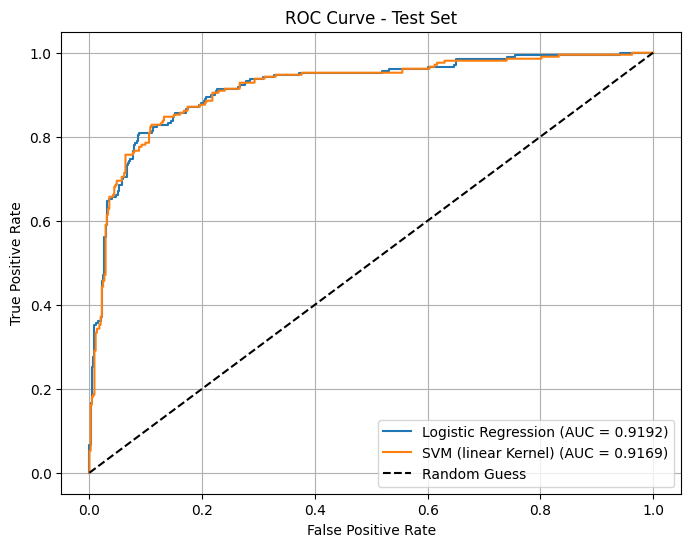


Final Test Set Evaluation:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.8569     0.7468  0.8286    0.7856   0.9192
1  SVM (linear Kernel)    0.8554     0.7355  0.8476    0.7876   0.9169


In [1174]:
final_lr = LogisticRegression(C=best_lr, penalty='l2', solver='liblinear', class_weight='balanced', random_state=42)
final_svm = SVC(C=best_svm, kernel='linear', probability=True, class_weight='balanced', random_state=42)

final_models = {
    "Logistic Regression": final_lr,
    "SVM (linear Kernel)": final_svm
}

X_final = pd.concat([pd.DataFrame(X_train), pd.DataFrame(X_val)])
y_final = np.concatenate((y_train.ravel(), y_val.ravel()))

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("=== 5-FOLD CROSS-VALIDATION RESULTS ===")
cv_results = []

for name, model in final_models.items():
    scores = cross_validate(model, X_final, y_final, cv=5, scoring=scoring)
    metrics = {metric: f"{np.mean(scores[f'test_{metric}']):.4f} ± {np.std(scores[f'test_{metric}']):.4f}" for metric in scoring}
    print(f"\n{name}:")
    for k, v in metrics.items():
        print(f"{k.capitalize()}: {v}")
    cv_results.append({'Model': name, **metrics})

print("\n\n=== FINAL EVALUATION ON TEST SET ===")
test_results = []
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (name, model) in enumerate(final_models.items()):
    model.fit(X_final, y_final)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Dropout', 'Dropout'],
                yticklabels=['Non-Dropout', 'Dropout'],
                ax=axes[idx])
    axes[idx].set_title(f"Confusion Matrix - {name}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f"\n{name} - Test Set:")
    print(classification_report(y_test, y_pred, target_names=["Non-Dropout", "Dropout"]))

    test_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": roc
    })

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for name, model in final_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend()
plt.grid(True)
plt.show()

df_test = pd.DataFrame(test_results).round(4)
print("\nFinal Test Set Evaluation:")
print(df_test)
